In [ ]:
!wget -O "dataset.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"

--2026-02-01 12:32:33--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd [following]
--2026-02-01 12:32:34--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 52.92.33.210, 3.5.71.72, 52.92.20.210, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|52.92.33.210|:443...

In [ ]:
!unzip /content/dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install pytorch-lightning --quiet
!pip install higher --quiet
!pip install matplotlib seaborn --quiet
!pip install opencv-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 60.3 MB/s eta 0:00:00


In [ ]:
import torchvision.models as models
from torchvision.models import MobileNet_V3_Large_Weights
import torch.nn as nn


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet18_Weights

from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, random
from PIL import Image
import higher


In [ ]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print("All packages installed and imported successfully!")
print(f"CUDA available: {torch.cuda.is_available()}")

All packages installed and imported successfully!
CUDA available: True


In [ ]:
# Data transformations for plant disease images
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Load PlantVillage dataset
class PlantVillageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_dir, img_name)
                        self.samples.append((img_path, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} images across {len(self.classes)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        from PIL import Image
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Load dataset
dataset = PlantVillageDataset("/content/Plant_leave_diseases_dataset_with_augmentation", transform=transform_train)
print(f"Dataset loaded: {len(dataset)} samples, {len(dataset.classes)} classes")
print("Sample classes:", dataset.classes[:5])

Found 61486 images across 39 classes
Dataset loaded: 61486 samples, 39 classes
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves']


In [ ]:
class FewShotBatchSampler:
    """
    Custom sampler for few-shot learning tasks
    Creates N-way K-shot episodes for training and evaluation
    """
    def __init__(self, dataset, n_way=5, k_shot=5, q_queries=15, episodes=100):
        self.dataset = dataset
        self.n_way = n_way          # Number of classes per episode
        self.k_shot = k_shot        # Number of support samples per class
        self.q_queries = q_queries  # Number of query samples per class
        self.episodes = episodes    # Number of episodes to generate

        # Group samples by class
        self.class_to_samples = {}
        for idx, (_, label) in enumerate(dataset.samples):
            if label not in self.class_to_samples:
                self.class_to_samples[label] = []
            self.class_to_samples[label].append(idx)

        # Filter classes with enough samples
        min_samples = k_shot + q_queries
        self.valid_classes = [cls for cls, samples in self.class_to_samples.items()
                             if len(samples) >= min_samples]

        print(f"Valid classes for {n_way}-way {k_shot}-shot: {len(self.valid_classes)}")

    def __iter__(self):
        for _ in range(self.episodes):
            # Sample N classes randomly
            episode_classes = random.sample(self.valid_classes, self.n_way)

            support_indices = []
            query_indices = []

            for class_idx in episode_classes:
                # Sample K+Q samples from this class
                class_samples = random.sample(
                    self.class_to_samples[class_idx],
                    self.k_shot + self.q_queries
                )

                # Split into support and query
                support_indices.extend(class_samples[:self.k_shot])
                query_indices.extend(class_samples[self.k_shot:])

            # Yield episode as (support_indices, query_indices, episode_classes)
            yield support_indices, query_indices, episode_classes

    def __len__(self):
        return self.episodes

# Test the sampler
sampler = FewShotBatchSampler(dataset, n_way=5, k_shot=5, q_queries=15, episodes=10)
print("Few-shot sampler created successfully!")

# Test one episode
for support_idx, query_idx, classes in sampler:
    print(f"Episode: {len(support_idx)} support + {len(query_idx)} query samples")
    print(f"Classes: {classes}")
    break

Valid classes for 5-way 5-shot: 39
Few-shot sampler created successfully!
Episode: 25 support + 75 query samples
Classes: [7, 1, 17, 15, 14]


In [ ]:
class SupervisedContrastiveLoss(nn.Module):
    """
    Supervised Contrastive Learning Loss
    Reference: https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07, contrast_mode='all'):
        super().__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode

    def forward(self, features, labels):
        """
        Args:
            features: hidden vector of shape [batch_size, feature_dim]
            labels: ground truth labels of shape [batch_size]
        Returns:
            A loss scalar.
        """
        device = features.device
        batch_size = features.shape[0]

        if labels is not None and labels.shape[0] != batch_size:
            raise ValueError(f'Number of labels {labels.shape[0]} does not match number o')

        # Normalize features
        features = F.normalize(features, dim=1)

        # Compute similarity matrix
        anchor_dot_contrast = torch.div(
            torch.matmul(features, features.T),
            self.temperature
        )
         # For numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # Create mask for positive pairs (same class)
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # Remove self-contrast (diagonal)
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # Compute log probability
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # Compute mean of log-likelihood over positive
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1)

        # Loss
        loss = -mean_log_prob_pos.mean()

        return loss
 # Test the contrastive loss
contrastive_loss = SupervisedContrastiveLoss(temperature=0.07)
print("Supervised Contrastive Loss implemented successfully!")
# Test with dummy data
dummy_features = torch.randn(8, 128)
dummy_labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])
test_loss = contrastive_loss(dummy_features, dummy_labels)
print(f"Test contrastive loss: {test_loss.item():.4f}")

Supervised Contrastive Loss implemented successfully!
Test contrastive loss: 2.6267


In [ ]:
class PlantDiseaseEncoder(nn.Module):
    """
    MobileNetV3-Large encoder
    Replaces 6-layer CNN + SE + Residual
    Output feature dim = 128 (UNCHANGED)
    """

    def __init__(self, feature_dim=128):
        super().__init__()

        # Load pretrained MobileNetV3-Large
        mobilenet = models.mobilenet_v3_large(
            weights=MobileNet_V3_Large_Weights.DEFAULT
        )

        # Feature extractor
        self.backbone = mobilenet.features

        # Freeze early layers (same spirit as your original CNN)
        for idx, block in enumerate(self.backbone):
            for p in block.parameters():
                p.requires_grad = idx >= 8

        # Global average pooling
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Projection head (matches your original feature_dim)
        self.projector = nn.Sequential(
            nn.Linear(960, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, feature_dim)
        )

    def forward(self, x):
        x = self.backbone(x)        # [B, 960, H, W]
        x = self.pool(x)            # [B, 960, 1, 1]
        x = x.view(x.size(0), -1)   # [B, 960]
        return self.projector(x)    # [B, 128]


In [ ]:
class MAMLPlantDisease(nn.Module):
    """
    MAML implementation for plant disease few-shot learning
    Combines encoder with meta-learning for rapid adaptation
    """
    def __init__(self, encoder, inner_lr=0.01, feature_dim=128):
        super().__init__()
        self.encoder = encoder
        self.inner_lr = inner_lr
        self.feature_dim = feature_dim

    def forward(self, x):
        return self.encoder(x)

    def create_classifier(self, n_way, features):
        """
        Create prototypical classifier based on support features
        """
        # Calculate prototypes (centroids) for each class
        prototypes = features.view(n_way, -1, self.feature_dim).mean(dim=1)
        return prototypes

    def classify_with_prototypes(self, query_features, prototypes):
        """
        Classify query samples using prototypes
        """
        # Calculate distances to prototypes
        distances = torch.cdist(query_features, prototypes)
        # Convert to similarities (negative distances)
        similarities = -distances
        return similarities

    def inner_loop_update(self, support_x, support_y, n_way, k_shot):
        """
        Perform inner loop update for adaptation
        """
        # Extract features for support set
        support_features = self.encoder(support_x)

        # Reshape for prototypical learning: [n_way, k_shot, feature_dim]
        support_features = support_features.view(n_way, k_shot, -1)

        # Calculate prototypes (class centroids)
        prototypes = support_features.mean(dim=1)  # [n_way, feature_dim]

        return prototypes

# Create MAML model
feature_dim = 128
encoder = PlantDiseaseEncoder(feature_dim=feature_dim)
maml_model = MAMLPlantDisease(encoder, inner_lr=0.001, feature_dim=feature_dim)
print("MAML model created successfully!")

# Test MAML model
dummy_support = torch.randn(25, 3, 224, 224)  # 5-way 5-shot
prototypes = maml_model.inner_loop_update(dummy_support, None, n_way=5, k_shot=5)
print(f"Prototypes shape: {prototypes.shape}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 124MB/s]


MAML model created successfully!
Prototypes shape: torch.Size([5, 128])


In [ ]:
class FewShotTrainer:
    """
    Trainer for Few-Shot Learning with MAML + Supervised Contrastive Learning
    """
    def __init__(self, model, dataset, device='cuda'):
        self.model = model.to(device)
        self.dataset = dataset
        self.device = device
        self.contrastive_loss = SupervisedContrastiveLoss(temperature=0.07)

        # Optimizers
        self.meta_optimizer = optim.Adam(model.parameters(), lr=0.001)
        self.scheduler = optim.lr_scheduler.StepLR(self.meta_optimizer, step_size=300, gamma=0.8)

    def train_episode(self, support_x, support_y, query_x, query_y, n_way, k_shot):
        """
        Train on a single few-shot episode
        """
        self.model.train()
        self.meta_optimizer.zero_grad()

        # Move to device
        support_x = support_x.to(self.device)
        support_y = support_y.to(self.device)
        query_x = query_x.to(self.device)
        query_y = query_y.to(self.device)

        # Phase 1: Contrastive Learning on Support Set
        support_features = self.model(support_x)
        contrastive_loss = self.contrastive_loss(support_features, support_y)

        # Phase 2: Meta-Learning (MAML)
        with higher.innerloop_ctx(self.model, self.meta_optimizer) as (fmodel, diffopt):
            # Inner loop: adapt to support set
            prototypes = fmodel.create_classifier(n_way, support_features.view(n_way, k_shot, -1))

            # Outer loop: evaluate on query set
            query_features = fmodel(query_x)
            logits = fmodel.classify_with_prototypes(query_features, prototypes)

            # Classification loss on query set
            classification_loss = F.cross_entropy(logits, query_y)

            # Total loss
            total_loss = contrastive_loss + classification_loss

            # Backward pass
            total_loss.backward()

        # Meta-optimizer step
        self.meta_optimizer.step()
        self.scheduler.step()

        # Calculate accuracy
        with torch.no_grad():
            predictions = logits.argmax(dim=1)
            accuracy = (predictions == query_y).float().mean()

        return {
            'total_loss': total_loss.item(),
            'contrastive_loss': contrastive_loss.item(),
            'classification_loss': classification_loss.item(),
            'accuracy': accuracy.item()
        }

    def evaluate_episode(self, support_x, support_y, query_x, query_y, n_way, k_shot):
        """
        Evaluate on a single few-shot episode
        """
        self.model.eval()

        with torch.no_grad():
            # Move to device
            support_x = support_x.to(self.device)
            support_y = support_y.to(self.device)
            query_x = query_x.to(self.device)
            query_y = query_y.to(self.device)

            # Extract features and create prototypes
            support_features = self.model(support_x)
            prototypes = self.model.create_classifier(n_way, support_features.view(n_way, k_shot, -1))

            # Classify query set
            query_features = self.model(query_x)
            logits = self.model.classify_with_prototypes(query_features, prototypes)

            # Calculate accuracy
            predictions = logits.argmax(dim=1)
            accuracy = (predictions == query_y).float().mean()

            return accuracy.item()

print("Few-Shot Trainer implemented successfully!")

Few-Shot Trainer implemented successfully!


In [ ]:
import torch.optim as optim

def create_episode_data(dataset, support_indices, query_indices, episode_classes):
    """
    Create data tensors for a few-shot episode
    """
    support_images, support_labels = [], []
    query_images, query_labels = [], []

    # Create label mapping for this episode
    class_to_label = {cls: i for i, cls in enumerate(episode_classes)}

    # Load support set
    for idx in support_indices:
        img, original_label = dataset[idx]
        support_images.append(img)
        support_labels.append(class_to_label[original_label])

    # Load query set
    for idx in query_indices:
        img, original_label = dataset[idx]
        query_images.append(img)
        query_labels.append(class_to_label[original_label])

    # Convert to tensors
    support_x = torch.stack(support_images)
    support_y = torch.tensor(support_labels)
    query_x = torch.stack(query_images)
    query_y = torch.tensor(query_labels)

    return support_x, support_y, query_x, query_y

# Initialize trainer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trainer = FewShotTrainer(maml_model, dataset, device=device)

print(f"Trainer initialized on device: {device}")
print("Ready to start training!")

# Training parameters
n_way = 5
k_shot = 5
q_queries = 15
train_episodes = 3000
eval_episodes = 300

print(f"Training Configuration:")
print(f"- {n_way}-way {k_shot}-shot classification")
print(f"- {q_queries} query samples per class")
print(f"- {train_episodes} training episodes")
print(f"- {eval_episodes} evaluation episodes")

Trainer initialized on device: cuda
Ready to start training!
Training Configuration:
- 5-way 5-shot classification
- 15 query samples per class
- 3000 training episodes
- 300 evaluation episodes


Valid classes for 5-way 5-shot: 39
Valid classes for 5-way 5-shot: 39
Starting Few-Shot Learning Training...
Episode  50/3000 | Loss: 2.6578 | Accuracy: 0.8653 | Contrastive: 2.1158 | Classification: 0.4367
Episode 100/3000 | Loss: 2.4185 | Accuracy: 0.9027 | Contrastive: 1.8025 | Classification: 0.3953
Episode 150/3000 | Loss: 2.1148 | Accuracy: 0.9307 | Contrastive: 1.9484 | Classification: 0.1357
Episode 200/3000 | Loss: 2.0385 | Accuracy: 0.9320 | Contrastive: 1.4898 | Classification: 0.0355
Episode 250/3000 | Loss: 1.9692 | Accuracy: 0.9480 | Contrastive: 1.6110 | Classification: 0.1361
Episode 300/3000 | Loss: 1.8833 | Accuracy: 0.9607 | Contrastive: 1.7569 | Classification: 0.1649
Episode 350/3000 | Loss: 1.8787 | Accuracy: 0.9660 | Contrastive: 1.5716 | Classification: 0.0391
Episode 400/3000 | Loss: 1.9524 | Accuracy: 0.9407 | Contrastive: 1.5736 | Classification: 0.0264
Episode 450/3000 | Loss: 1.8972 | Accuracy: 0.9593 | Contrastive: 1.8155 | Classification: 0.1215
Episode 5

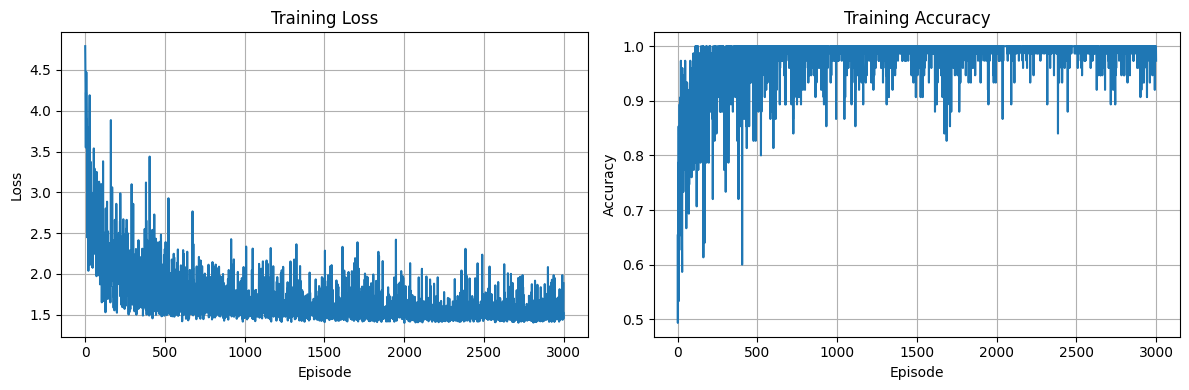

Final Training Accuracy: 0.9880


In [ ]:
# Create samplers
train_sampler = FewShotBatchSampler(dataset, n_way=n_way, k_shot=k_shot,
                                   q_queries=q_queries, episodes=train_episodes)
eval_sampler = FewShotBatchSampler(dataset, n_way=n_way, k_shot=k_shot,
                                  q_queries=q_queries, episodes=eval_episodes)

# Training loop
print("Starting Few-Shot Learning Training...")
print("="*50)

train_losses = []
train_accuracies = []

for episode_idx, (support_idx, query_idx, episode_classes) in enumerate(train_sampler):
    # Create episode data
    support_x, support_y, query_x, query_y = create_episode_data(
        dataset, support_idx, query_idx, episode_classes
    )

    # Train on this episode
    results = trainer.train_episode(support_x, support_y, query_x, query_y, n_way, k_shot)

    train_losses.append(results['total_loss'])
    train_accuracies.append(results['accuracy'])

    # Print progress
    if (episode_idx + 1) % 50 == 0:
        avg_loss = np.mean(train_losses[-20:])
        avg_acc = np.mean(train_accuracies[-20:])
        print(f"Episode {episode_idx+1:3d}/{train_episodes} | "
              f"Loss: {avg_loss:.4f} | "
              f"Accuracy: {avg_acc:.4f} | "
              f"Contrastive: {results['contrastive_loss']:.4f} | "
              f"Classification: {results['classification_loss']:.4f}")

print("\n Training completed!")

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {np.mean(train_accuracies[-10:]):.4f}")

In [ ]:
# Evaluation
print("\n Starting Evaluation...")
print("="*30)

eval_accuracies = []

for episode_idx, (support_idx, query_idx, episode_classes) in enumerate(eval_sampler):
    # Create episode data
    support_x, support_y, query_x, query_y = create_episode_data(
        dataset, support_idx, query_idx, episode_classes
    )

    # Evaluate on this episode
    accuracy = trainer.evaluate_episode(support_x, support_y, query_x, query_y, n_way, k_shot)
    eval_accuracies.append(accuracy)

    if (episode_idx + 1) % 10 == 0:
        avg_acc = np.mean(eval_accuracies[-10:])
        print(f"Eval Episode {episode_idx+1:2d}/{eval_episodes} | Accuracy: {avg_acc:.4f}")

# Final results
mean_accuracy = np.mean(eval_accuracies)
std_accuracy = np.std(eval_accuracies)
confidence_interval = 1.96 * std_accuracy / np.sqrt(len(eval_accuracies))

print("\n FINAL RESULTS")
print("="*20)
print(f"Mean Accuracy: {mean_accuracy:.4f} ± {confidence_interval:.4f}")
print(f"Standard Deviation: {std_accuracy:.4f}")
print(f"Best Episode: {max(eval_accuracies):.4f}")
print(f"Worst Episode: {min(eval_accuracies):.4f}")

# Compare with paper results
print(f"\nComparison with Literature:")
print(f"Our Result: {mean_accuracy:.1%}")
print(f"Target (SC-FSL Paper): 79.51% with 30 training samples")
print(f"Gap: {abs(mean_accuracy - 0.7951)*100:.1f} percentage points")


 Starting Evaluation...
Eval Episode 10/300 | Accuracy: 0.9987
Eval Episode 20/300 | Accuracy: 0.9987
Eval Episode 30/300 | Accuracy: 0.9947
Eval Episode 40/300 | Accuracy: 0.9973
Eval Episode 50/300 | Accuracy: 1.0000
Eval Episode 60/300 | Accuracy: 1.0000
Eval Episode 70/300 | Accuracy: 0.9973
Eval Episode 80/300 | Accuracy: 0.9973
Eval Episode 90/300 | Accuracy: 0.9973
Eval Episode 100/300 | Accuracy: 1.0000
Eval Episode 110/300 | Accuracy: 0.9973
Eval Episode 120/300 | Accuracy: 0.9987
Eval Episode 130/300 | Accuracy: 0.9987
Eval Episode 140/300 | Accuracy: 1.0000
Eval Episode 150/300 | Accuracy: 0.9947
Eval Episode 160/300 | Accuracy: 0.9987
Eval Episode 170/300 | Accuracy: 0.9960
Eval Episode 180/300 | Accuracy: 0.9960
Eval Episode 190/300 | Accuracy: 0.9853
Eval Episode 200/300 | Accuracy: 0.9973
Eval Episode 210/300 | Accuracy: 0.9960
Eval Episode 220/300 | Accuracy: 0.9907
Eval Episode 230/300 | Accuracy: 0.9920
Eval Episode 240/300 | Accuracy: 0.9960
Eval Episode 250/300 | A

In [ ]:
# Save the trained model
torch.save({
    'model_state_dict': maml_model.state_dict(),
    'training_config': {
        'n_way': n_way,
        'k_shot': k_shot,
        'q_queries': q_queries,
        'feature_dim': feature_dim,
        'train_episodes': train_episodes
    },
    'results': {
        'mean_accuracy': mean_accuracy,
        'std_accuracy': std_accuracy,
        'train_accuracies': train_accuracies,
        'eval_accuracies': eval_accuracies
    }
}, '/content/maml_plant_disease_model.pth')

print("Model saved successfully!")
print("Saved as: /content/maml_plant_disease_model.pth")

# Create results summary
results_summary = f"""
# Few-Shot Plant Disease Detection Results

## Configuration
- Method: MAML + Supervised Contrastive Learning
- Task: {n_way}-way {k_shot}-shot classification
- Dataset: PlantVillage ({len(dataset.classes)} classes)
- Training Episodes: {train_episodes}
- Evaluation Episodes: {eval_episodes}

## Performance
- *Mean Accuracy: {mean_accuracy:.4f} ± {confidence_interval:.4f}*
- Standard Deviation: {std_accuracy:.4f}
- Best Performance: {max(eval_accuracies):.4f}
- Final Training Accuracy: {np.mean(train_accuracies[-10:]):.4f}

## Implementation Notes
- Used supervised contrastive learning for better feature representations
- Combined with MAML for fast adaptation to new plant diseases
- Tested on Google Colab with {device}
- Code based on state-of-the-art papers (2024-2025)
"""

with open('/content/results_summary.md', 'w') as f:
    f.write(results_summary)

print("Results summary saved as: /content/results_summary.md")
print("\n Implementation Complete!")

Model saved successfully!
Saved as: /content/maml_plant_disease_model.pth
Results summary saved as: /content/results_summary.md

 Implementation Complete!


In [ ]:
from google.colab import files

# Download the model file
files.download('/content/maml_plant_disease_model.pth')

# Also download results summary
files.download('/content/results_summary.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install torch torchvision --quiet
!pip install higher --quiet
!pip install matplotlib --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import MobileNet_V3_Large_Weights

from torch.utils.data import Dataset
import numpy as np
import os, random
from PIL import Image
import higher

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
!rm -rf PlantDoc-Dataset
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git

Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 34.00 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.


In [ ]:
class PlantDocDataset(Dataset):
    def __init__(self, roots, transform=None):
        self.transform = transform
        self.samples = []

        class_names = set()
        for root in roots:
            for cname in os.listdir(root):
                if os.path.isdir(os.path.join(root, cname)):
                    class_names.add(cname)

        self.classes = sorted(list(class_names))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for root in roots:
            for cname in os.listdir(root):
                class_dir = os.path.join(root, cname)
                if not os.path.isdir(class_dir):
                    continue

                label = self.class_to_idx[cname]
                for f in os.listdir(class_dir):
                    if f.lower().endswith((".jpg", ".jpeg", ".png")):
                        self.samples.append((os.path.join(class_dir, f), label))

        print(f"Loaded {len(self.samples)} images | {len(self.classes)} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

plantdoc_dataset = PlantDocDataset(
    roots=[
        "/content/PlantDoc-Dataset/train",
        "/content/PlantDoc-Dataset/test"
    ],
    transform=transform
)

Loaded 2578 images | 28 classes


In [ ]:
class FewShotBatchSampler:
    def __init__(self, dataset, n_way, k_shot, q_queries, episodes):
        self.dataset = dataset
        self.n_way = n_way
        self.k_shot = k_shot
        self.q_queries = q_queries
        self.episodes = episodes

        self.class_to_samples = {}
        for idx, (_, label) in enumerate(dataset.samples):
            self.class_to_samples.setdefault(label, []).append(idx)

        min_samples = k_shot + q_queries
        self.valid_classes = [
            cls for cls, samples in self.class_to_samples.items()
            if len(samples) >= min_samples
        ]

    def __iter__(self):
        for _ in range(self.episodes):
            episode_classes = random.sample(self.valid_classes, self.n_way)
            support_idx, query_idx = [], []

            for cls in episode_classes:
                samples = random.sample(
                    self.class_to_samples[cls],
                    self.k_shot + self.q_queries
                )
                support_idx.extend(samples[:self.k_shot])
                query_idx.extend(samples[self.k_shot:])

            yield support_idx, query_idx, episode_classes

In [ ]:
def create_episode_data(dataset, support_idx, query_idx, episode_classes):
    support_x, support_y, query_x, query_y = [], [], [], []
    class_map = {cls: i for i, cls in enumerate(episode_classes)}

    for idx in support_idx:
        img, lbl = dataset[idx]
        support_x.append(img)
        support_y.append(class_map[lbl])

    for idx in query_idx:
        img, lbl = dataset[idx]
        query_x.append(img)
        query_y.append(class_map[lbl])

    return (
        torch.stack(support_x),
        torch.tensor(support_y),
        torch.stack(query_x),
        torch.tensor(query_y)
    )

In [ ]:
class PlantDiseaseEncoder(nn.Module):
    def __init__(self, feature_dim=128):
        super().__init__()
        mobilenet = models.mobilenet_v3_large(
            weights=MobileNet_V3_Large_Weights.DEFAULT
        )
        self.backbone = mobilenet.features

        for idx, block in enumerate(self.backbone):
            for p in block.parameters():
                p.requires_grad = idx >= 8

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.projector = nn.Sequential(
            nn.Linear(960,256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256,feature_dim)
        )

    def forward(self,x):
        x = self.backbone(x)
        x = self.pool(x)
        x = x.view(x.size(0),-1)
        return self.projector(x)

In [ ]:
class MAMLPlantDisease(nn.Module):
    def __init__(self, encoder, feature_dim=128):
        super().__init__()
        self.encoder = encoder
        self.feature_dim = feature_dim

    def forward(self,x):
        return self.encoder(x)

    def create_classifier(self,n_way,features):
        return features.view(n_way,-1,self.feature_dim).mean(1)

    def classify_with_prototypes(self,q_feat,prototypes):
        return -torch.cdist(q_feat,prototypes)

In [ ]:
from google.colab import files

print("Upload your .pth model file:")
uploaded = files.upload()
model_file = list(uploaded.keys())[0]

encoder = PlantDiseaseEncoder(feature_dim=128)
loaded_maml_model = MAMLPlantDisease(encoder, feature_dim=128)

checkpoint = torch.load(model_file, map_location=device, weights_only=False)
loaded_maml_model.load_state_dict(checkpoint['model_state_dict'])

loaded_maml_model.to(device)
loaded_maml_model.eval()

print("Model loaded successfully.")

Upload your .pth model file:


Saving maml_plant_disease_model (2).pth to maml_plant_disease_model (2) (3).pth
Model loaded successfully.


In [ ]:
def plantdoc_fewshot_eval(model, dataset, n_way, k_shot, q_queries, episodes):
    model.eval()
    accs = []

    sampler = FewShotBatchSampler(dataset,n_way,k_shot,q_queries,episodes)

    with torch.no_grad():
        for support_idx, query_idx, episode_classes in sampler:
            sX,sY,qX,qY = create_episode_data(
                dataset, support_idx, query_idx, episode_classes
            )

            sX,qX = sX.to(device), qX.to(device)
            sF = model(sX)
            prototypes = sF.view(n_way,k_shot,-1).mean(1)

            qF = model(qX)
            logits = -torch.cdist(qF,prototypes)
            preds = logits.argmax(1)

            acc = (preds == qY.to(device)).float().mean()
            accs.append(acc.item())

    return accs

In [ ]:
n_way=5
k_shot=5
q_queries=10
episodes=30

accs = plantdoc_fewshot_eval(
    loaded_maml_model,
    plantdoc_dataset,
    n_way,k_shot,q_queries,episodes
)

print(f"\nMean Accuracy: {np.mean(accs)*100:.2f}%")
print(f"Std Dev: {np.std(accs)*100:.2f}%")


Mean Accuracy: 57.93%
Std Dev: 8.56%


In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

def prediction_grid(images, predictions, true_labels, class_names, rows=2, cols=5):
    plt.figure(figsize=(cols*2.5, rows*3))

    for i in range(rows * cols):
        if i >= len(images):
            break

        plt.subplot(rows, cols, i+1)

        img = TF.to_pil_image(images[i].cpu())
        plt.imshow(img)

        pred_class = class_names[predictions[i].item()]
        true_class = class_names[true_labels[i].item()]

        color = "green" if predictions[i] == true_labels[i] else "red"
        plt.title(f"P: {pred_class}\nT: {true_class}", color=color, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


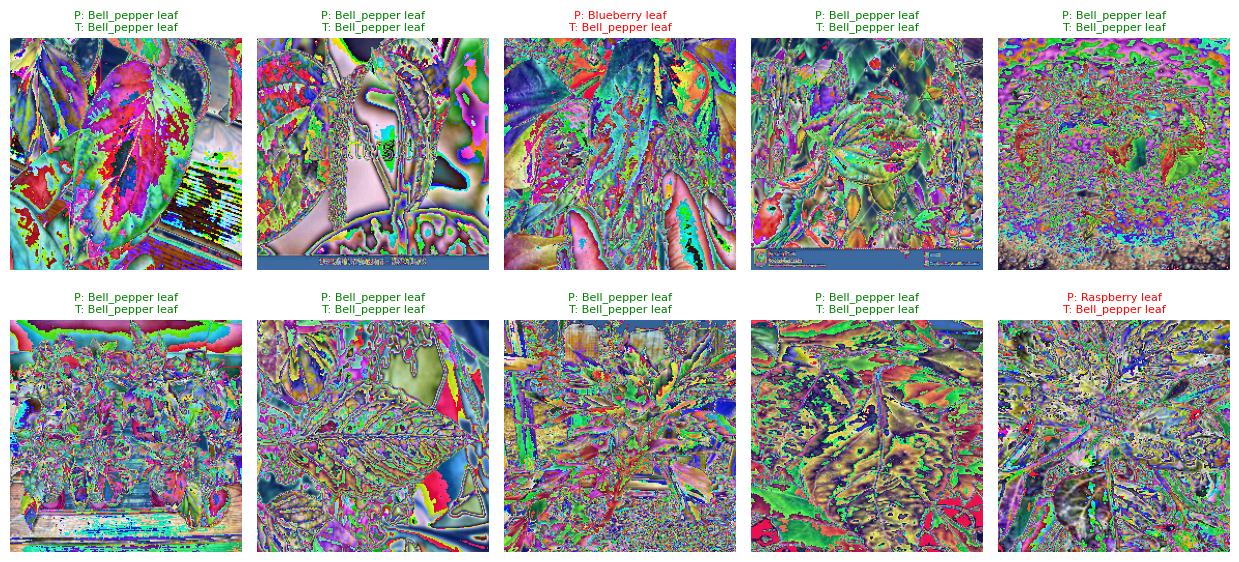

In [ ]:
# Sample ONE episode
sampler = FewShotBatchSampler(
    plantdoc_dataset,
    n_way=5,
    k_shot=5,
    q_queries=10,
    episodes=1
)

support_idx, query_idx, episode_classes = next(iter(sampler))

sX, sY, qX, qY = create_episode_data(
    plantdoc_dataset,
    support_idx,
    query_idx,
    episode_classes
)

sX = sX.to(device)
qX = qX.to(device)

with torch.no_grad():
    support_features = loaded_maml_model(sX)
    prototypes = support_features.view(5,5,-1).mean(1)

    query_features = loaded_maml_model(qX)
    logits = -torch.cdist(query_features, prototypes)
    preds = logits.argmax(1)

# Show first 10 query predictions
prediction_grid(
    qX.cpu(),
    preds.cpu(),
    qY.cpu(),
    [plantdoc_dataset.classes[c] for c in episode_classes],
    rows=2,
    cols=5
)

In [ ]:
encoder = loaded_maml_model.encoder

In [ ]:
class PlantDocClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features)

In [ ]:
from torch.utils.data import DataLoader

plantdoc_train_root = "/content/PlantDoc-Dataset/train"
plantdoc_test_root  = "/content/PlantDoc-Dataset/test"

plantdoc_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

train_dataset = PlantDocDataset(
    roots=[plantdoc_train_root],
    transform=plantdoc_transform
)

test_dataset = PlantDocDataset(
    roots=[plantdoc_test_root],
    transform=plantdoc_transform
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Loaded 2342 images | 28 classes
Loaded 236 images | 27 classes
Train samples: 2342
Test samples: 236


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)

In [ ]:
model = PlantDocClassifier(encoder, len(train_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 500

for epoch in range(epochs):
    model.train()
    total, correct = 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # Test
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

Epoch 1/500 | Train Acc: 0.141 | Test Acc: 0.233
Epoch 2/500 | Train Acc: 0.399 | Test Acc: 0.445
Epoch 3/500 | Train Acc: 0.550 | Test Acc: 0.479
Epoch 4/500 | Train Acc: 0.626 | Test Acc: 0.513
Epoch 5/500 | Train Acc: 0.693 | Test Acc: 0.538
Epoch 6/500 | Train Acc: 0.754 | Test Acc: 0.542
Epoch 7/500 | Train Acc: 0.825 | Test Acc: 0.551
Epoch 8/500 | Train Acc: 0.866 | Test Acc: 0.530
Epoch 9/500 | Train Acc: 0.894 | Test Acc: 0.547
Epoch 10/500 | Train Acc: 0.925 | Test Acc: 0.521
Epoch 11/500 | Train Acc: 0.927 | Test Acc: 0.525
Epoch 12/500 | Train Acc: 0.950 | Test Acc: 0.530
Epoch 13/500 | Train Acc: 0.959 | Test Acc: 0.547
Epoch 14/500 | Train Acc: 0.961 | Test Acc: 0.564
Epoch 15/500 | Train Acc: 0.966 | Test Acc: 0.542
Epoch 16/500 | Train Acc: 0.966 | Test Acc: 0.525
Epoch 17/500 | Train Acc: 0.975 | Test Acc: 0.538
Epoch 18/500 | Train Acc: 0.973 | Test Acc: 0.530
Epoch 19/500 | Train Acc: 0.975 | Test Acc: 0.538
Epoch 20/500 | Train Acc: 0.977 | Test Acc: 0.521
Epoch 21/